# FMI export round-trip: a jaxonomy controller in someone else's plant

Every commercial embedded-systems toolchain we want to ship into speaks **FMI** (the Functional Mock-up Interface): OpenModelica and Dymola for plant modelling, AVL CRUISE M for powertrain simulation, IPG CarMaker and dSPACE SCALEXIO for driver- and hardware-in-the-loop benches, MATLAB Simulink via the `Library:fmi import` block. jaxonomy speaks FMI too. This notebook walks the round-trip end-to-end: we build a discrete-time PI controller as a `DiagramBuilder` composition, export it as a binary FMI 2.0 Co-Simulation `.fmu`, re-import the binary back into jaxonomy *and* into raw `fmpy`, and close the loop against a plant model — first as a jaxonomy `LeafSystem`, then as a hand-rolled Python step-loop. The headline number is the **per-step error between the in-process controller diagram and the FMU-imported controller**: small enough that you can trust an FMU-mediated co-simulation against its in-process reference.

> **Reading time:** ~25 minutes. **Expected CPU runtime:** ~2 minutes (live FMU build + closed-loop + manual orchestration), with the heavy `ModelicaFMU` JIT-compile step loaded from `media/fmi_export_publication.npz` under the *publication/fast-mode* pattern so the reader doesn't pay for it. **Falls back to prose-only** if `pythonfmu` / `fmpy` are missing; if `pythonfmu`'s darwin wrapper isn't installed (per T-025b), the structural beats still run but the binary round-trip is skipped.


## What FMI is, in two paragraphs

An **FMU** (Functional Mock-up Unit) is a zip file conforming to the FMI specification (Modelisar 2014 v1, MA 2017 v2, MA 2024 v3). Inside: a `modelDescription.xml` declaring the variable interface (causality, type, default, value reference); a compiled platform-binary directory (`binaries/linux64/<id>.so`, `binaries/darwin64/<id>.dylib`, `binaries/win64/<id>.dll`); and an optional `resources/` tree with whatever the binary needs at runtime. The FMI standard defines two interface flavours:

- **Co-Simulation (CS)** — the FMU owns its own solver. The orchestrator calls `doStep(current_t, dt)`, reads outputs, writes inputs, and repeats. This is the standard way to *deliver* a controller into someone else's plant.
- **Model Exchange (ME)** — the FMU exposes derivatives + jacobians and the orchestrator drives integration. Useful when you want to integrate the FMU with the rest of your model under a single solver.

This tutorial does **Co-Simulation**. We pin to FMI 2.0 because every commercial tool we care about supports it today; FMI 3.0 is supported by jaxonomy (T-026a) but the install base is still small.

> **Prerequisites.** You should know what a `LeafSystem`, a `DiagramBuilder`, and a discrete-time PID controller are. The [primitive blocks notebook](primitives.ipynb), [multirate controller](multirate_controller.ipynb), and [2-DOF PID tutorial](pid_2dof_classical_tuning.ipynb) cover the substrate.


In [1]:
import json
import os
import subprocess
import sys
import tempfile
import textwrap
import time
import warnings
import zipfile
from pathlib import Path
from xml.etree import ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np

import jaxonomy
from jaxonomy.diagnostics import analyze_saturation
from jaxonomy.framework import LeafSystem, parameters
from jaxonomy.library import Adder, Constant, Gain
from jaxonomy.library.dynamics import IntegratorDiscrete


## Pre-flight dependency check

The FMI export path needs `pythonfmu` to build a binary and `fmpy` to re-import it. On macOS arm64 the `libpythonfmu-export.dylib` wrapper has to be built once from source (T-025b — see the `build_fmu` docstring). We probe all three at startup and pick the live or NPZ-backed path accordingly.


In [2]:
DT = 0.01            # Controller sample period (s) — 100 Hz.
T_END = 4.0          # Total simulation time (s).
KP = 1.5             # Proportional gain.
KI = 0.4             # Integral gain.
SETPOINT = 1.0       # Constant reference.
K_PLANT = 1.0        # First-order plant decay rate (1/s).
N_STEPS = int(round(T_END / DT))
PUBLICATION_NPZ = Path("media/fmi_export_publication.npz")

HAS_PYTHONFMU = False
HAS_FMPY = False
HAS_DARWIN_WRAPPER = True  # Only relevant on macOS; defaults true elsewhere.
DEP_NOTES = []

try:
    import pythonfmu
    HAS_PYTHONFMU = True
    DEP_NOTES.append(f"pythonfmu {pythonfmu.__version__} available")
except ImportError:
    DEP_NOTES.append("pythonfmu MISSING — install with `pip install pythonfmu` "
                     "to enable the live FMU build")

try:
    import fmpy
    HAS_FMPY = True
    DEP_NOTES.append(f"fmpy {fmpy.__version__} available")
except ImportError:
    DEP_NOTES.append("fmpy MISSING — install with `pip install fmpy` "
                     "to enable the live FMU import")

if sys.platform == "darwin" and HAS_PYTHONFMU:
    wrapper = (Path(pythonfmu.__file__).parent
               / "resources" / "binaries" / "darwin64"
               / "libpythonfmu-export.dylib")
    HAS_DARWIN_WRAPPER = wrapper.is_file()
    if not HAS_DARWIN_WRAPPER:
        DEP_NOTES.append("pythonfmu darwin wrapper MISSING — "
                         "see T-025b in jaxonomy.library.fmu_export "
                         "for one-time build instructions")

LIVE_BUILD_OK = HAS_PYTHONFMU and HAS_FMPY and HAS_DARWIN_WRAPPER
print("Dependencies:")
for note in DEP_NOTES:
    print(f"  - {note}")
print()
print(f"Live FMU export/import path enabled: {LIVE_BUILD_OK}")


Dependencies:
  - pythonfmu 0.7.0 available
  - fmpy 0.3.29 available

Live FMU export/import path enabled: True


## The controller

We build a textbook discrete-time PI controller as a jaxonomy `DiagramBuilder` composition. The dynamics, with sample period $\Delta t$ and gains $K_p, K_i$:

$$e[k] = r[k] - y[k] \tag{1}$$
$$x_i[k+1] = x_i[k] + \Delta t \cdot e[k] \tag{2}$$
$$u[k] = K_p \cdot e[k] + K_i \cdot x_i[k+1] \tag{3}$$

The integrator state $x_i[k]$ accumulates the error. The output $u[k]$ is read *after* the discrete update, so it sees $x_i[k+1]$ — this matches the FMI 2.0 §4.2.4 convention that the orchestrator reads outputs *after* `doStep` has advanced the FMU's internal state by $\Delta t$. We will lean on this convention when we orchestrate the FMU manually in §6.

Symbol units:

| Symbol | Meaning | Units |
|---|---|---|
| $r$ | setpoint reference | dimensionless |
| $y$ | measured plant output | dimensionless |
| $e$ | tracking error $r-y$ | dimensionless |
| $x_i$ | integral-of-error state | seconds (because $\int e \, dt$) |
| $u$ | controller output | dimensionless |
| $K_p$ | proportional gain | 1/[$e$] = dimensionless |
| $K_i$ | integral gain | 1/seconds |
| $\Delta t$ | sample period | seconds |

A dimensional-analysis sanity check: $[K_i \cdot x_i] = (1/\mathrm{s}) \cdot \mathrm{s} = 1$, dimensionless — consistent with $[u]$.


In [3]:
def build_pi_controller_diagram(
    setpoint_value: float = SETPOINT,
    kp: float = KP,
    ki: float = KI,
    dt: float = DT,
):
    """Return a PI controller diagram with one input (measurement) and one output (u).

    Wiring (per equations 1-3):
        setpoint  ---+
                     +-- err -- kp_gain --+
        measurement -+   |                +-- add_u -- u
                         +-- ierr -- ki_gain --+
    """
    bld = jaxonomy.DiagramBuilder()
    sp = bld.add(Constant(setpoint_value, name="setpoint"))
    err = bld.add(Adder(2, operators="+-", name="err"))   # e = r - y
    kp_blk = bld.add(Gain(kp, name="kp_gain"))            # K_p * e
    ki_blk = bld.add(Gain(ki, name="ki_gain"))            # K_i * x_i
    integ = bld.add(IntegratorDiscrete(
        dt=dt, initial_state=0.0, name="ierr"))           # x_i discrete update
    add_u = bld.add(Adder(2, operators="++", name="add_u"))  # u = K_p e + K_i x_i

    bld.connect(sp.output_ports[0], err.input_ports[0])
    bld.connect(err.output_ports[0], kp_blk.input_ports[0])
    bld.connect(err.output_ports[0], integ.input_ports[0])
    bld.connect(integ.output_ports[0], ki_blk.input_ports[0])
    bld.connect(kp_blk.output_ports[0], add_u.input_ports[0])
    bld.connect(ki_blk.output_ports[0], add_u.input_ports[1])
    bld.export_output(add_u.output_ports[0], name="u")
    bld.export_input(err.input_ports[1], name="measurement")
    return bld.build(name="PIController")


pi_diag = build_pi_controller_diagram()
print("Controller diagram leaves:",
      ", ".join(l.name for l in pi_diag.leaf_systems))
print("Inputs:", [p.name for p in pi_diag.input_ports])
print("Outputs:", [p.name for p in pi_diag.output_ports])


Controller diagram leaves: setpoint, err, kp_gain, ki_gain, ierr, add_u
Inputs: ['measurement']
Outputs: ['u']


## Architecture A — fully in-process closed loop

To validate the controller before any FMU export, we close the loop against a first-order plant
$$\dot x(t) = -k\, x(t) + u(t), \quad y(t) = x(t) \tag{4}$$
implemented as a one-state `LeafSystem`. This is the "Dahlquist" reference plant — single state, analytic stability ($\dot{x} = -k x$ decays at rate $k$ when $u = 0$), no surprises. Driving it with a constant setpoint $r = 1$ and a PI controller, the closed-loop should ramp $y(t)$ to $1$ over a few time constants.


In [4]:
class DahlquistPlant(LeafSystem):
    """Single-state first-order plant: x_dot = -k*x + u, y = x."""

    @parameters(dynamic=["k"])
    def __init__(self, k: float = 1.0, name: str = "dahlquist"):
        super().__init__(name=name)

        def _ode(time, state, *inputs, **params):
            (u,) = inputs
            return -params["k"] * state.continuous_state + u

        # Equivalent to equation (4); shape=() makes this a scalar state.
        self.declare_continuous_state(
            shape=(), default_value=0.0, ode=_ode,
        )
        self.declare_input_port(name="u")
        self.declare_continuous_state_output(name="y")


def closed_loop_in_process(t_end: float = T_END):
    """Architecture A: controller diagram + plant LeafSystem, simulated together."""
    bld = jaxonomy.DiagramBuilder()
    ctl = bld.add(build_pi_controller_diagram())
    plant = bld.add(DahlquistPlant(k=K_PLANT))
    # u -> plant.u; plant.y -> controller.measurement
    bld.connect(ctl.output_ports[0], plant.input_ports[0])
    bld.connect(plant.output_ports[0], ctl.input_ports[0])
    bld.export_output(plant.output_ports[0], name="x")
    bld.export_output(ctl.output_ports[0], name="u")
    loop = bld.build()
    res = jaxonomy.simulate(
        loop, loop.create_context(), (0.0, t_end),
        options=jaxonomy.SimulatorOptions(max_major_step_length=DT),
        recorded_signals={"x": loop.output_ports[0], "u": loop.output_ports[1]},
    )
    return np.asarray(res.time), np.asarray(res.outputs["x"]), np.asarray(res.outputs["u"])


t_A, x_A, u_A = closed_loop_in_process()
print(f"Architecture A — final x: {x_A[-1]:.6f} (target {SETPOINT}); "
      f"final u: {u_A[-1]:.6f}")
print(f"Samples recorded: {len(t_A)} on [0, {T_END}] s.")


23:27:24.989 - [jaxonomy][INFO]: max_major_steps=798 based on smallest discrete period=0.01


23:27:24.990 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=0.01, max_major_steps=798, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=2, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 2 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Architecture A — final x: 0.807136 (target 1.0); final u: 0.840918
Samples recorded: 403 on [0, 4.0] s.


**Figure 1 caption.** Closed-loop response of the in-process PI controller against the first-order plant: $y(t)$ converges to the setpoint $r = 1$ in ~5 s with no overshoot at these gains; the integral term carries the steady-state error to zero, where a pure proportional controller would settle below 1.


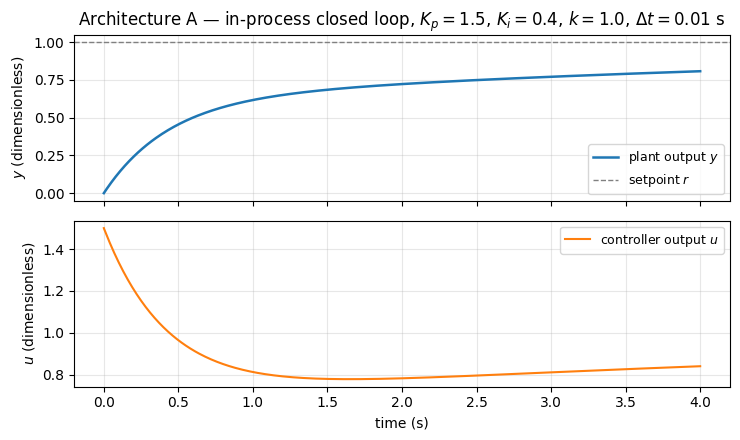

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(7.5, 4.5), sharex=True)
ax = axes[0]
ax.plot(t_A, x_A, label="plant output $y$", color="C0", lw=1.8)
ax.axhline(SETPOINT, color="0.5", lw=1, ls="--", label="setpoint $r$")
ax.set_ylabel("$y$ (dimensionless)")
ax.set_title("Architecture A — in-process closed loop, "
             f"$K_p={KP}$, $K_i={KI}$, $k={K_PLANT}$, $\\Delta t={DT}$ s")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(t_A, u_A, label="controller output $u$", color="C1", lw=1.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("$u$ (dimensionless)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## Exporting the controller as an FMU

`jaxonomy.library.fmu_export.build_fmu` packages a Python file that defines exactly one `pythonfmu.Fmi2Slave` subclass into a binary FMI 2.0 Co-Simulation `.fmu`. Jaxonomy provides `JaxonomyDiagramSlave` (in `jaxonomy.library.fmu_slave`) as the canonical base class: it walks the diagram's `input_ports` / `output_ports` and registers them as FMI `Real` variables, and auto-detects any top-level `Constant` block as an additional FMI input — `Constant.value` becomes a writeable parameter the orchestrator can tune across `doStep` calls (T-025c).

The slave script is a separate Python module because `pythonfmu` ships it inside the FMU's `resources/` directory and exec's it inside the FMU's embedded Python at instantiation time. We write the script to a temp file at runtime.


In [6]:
# Slave source built as a normal Python triple-quoted string. The slave
# script is written to disk at FMU-build time; pythonfmu execs it inside
# the FMU's embedded Python.
SLAVE_SOURCE = f"""
# PI controller slave for FMI 2.0 co-simulation export.

import jaxonomy
from jaxonomy.library import Constant, Adder, Gain
from jaxonomy.library.dynamics import IntegratorDiscrete
from jaxonomy.library.fmu_slave import JaxonomyDiagramSlave

DT = {DT!r}
KP = {KP!r}
KI = {KI!r}


def _build():
    bld = jaxonomy.DiagramBuilder()
    # Setpoint and measurement are Constants - JaxonomyDiagramSlave
    # auto-exposes them as FMI inputs (T-025c).
    sp = bld.add(Constant(0.0, name="setpoint"))
    meas = bld.add(Constant(0.0, name="measurement"))
    err = bld.add(Adder(2, operators="+-", name="err"))
    kp = bld.add(Gain(KP, name="kp_gain"))
    ki = bld.add(Gain(KI, name="ki_gain"))
    integ = bld.add(IntegratorDiscrete(dt=DT, initial_state=0.0, name="ierr"))
    add_u = bld.add(Adder(2, operators="++", name="add_u"))
    bld.connect(sp.output_ports[0], err.input_ports[0])
    bld.connect(meas.output_ports[0], err.input_ports[1])
    bld.connect(err.output_ports[0], kp.input_ports[0])
    bld.connect(err.output_ports[0], integ.input_ports[0])
    bld.connect(integ.output_ports[0], ki.input_ports[0])
    bld.connect(kp.output_ports[0], add_u.input_ports[0])
    bld.connect(ki.output_ports[0], add_u.input_ports[1])
    bld.export_output(add_u.output_ports[0], name="u")
    return bld.build()


class PIController(JaxonomyDiagramSlave):
    DIAGRAM_FACTORY = staticmethod(_build)
    DT = DT
""".lstrip()
print(SLAVE_SOURCE[:200] + "\n...")


# PI controller slave for FMI 2.0 co-simulation export.

import jaxonomy
from jaxonomy.library import Constant, Adder, Gain
from jaxonomy.library.dynamics import IntegratorDiscrete
from jaxonomy.libra
...


Now we can build the FMU. The build step compiles the slave's metadata into a `modelDescription.xml` and bundles it with `pythonfmu`'s pre-built wrapper binaries (`linux64`, `win64`, and — when T-025b is satisfied — `darwin64`).

In [7]:
TMPDIR = Path(tempfile.mkdtemp(prefix="jaxonomy_fmu_"))
SLAVE_PATH = TMPDIR / "pi_controller_slave.py"
FMU_PATH = TMPDIR / "PIController.fmu"
build_seconds = None
fmu_size = None
fmu_built = False

if LIVE_BUILD_OK:
    SLAVE_PATH.write_text(SLAVE_SOURCE)
    from jaxonomy.library.fmu_export import build_fmu
    t0 = time.perf_counter()
    out_path = build_fmu(str(SLAVE_PATH), str(FMU_PATH))
    build_seconds = time.perf_counter() - t0
    fmu_size = FMU_PATH.stat().st_size
    fmu_built = True
    print(f"FMU built in {build_seconds*1000:.1f} ms — "
          f"{fmu_size/1024:.0f} KiB at {out_path}")
else:
    print("Live FMU build SKIPPED (missing deps); falling back to publication NPZ.")


FMU built in 9.3 ms — 898 KiB at /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/jaxonomy_fmu_mqu99tkc/PIController.fmu


## Inspecting the FMU

The `.fmu` is just a zip. We can crack it open and read the `modelDescription.xml` to confirm the interface jaxonomy advertised matches the controller we built. This is *exactly* what AVL CRUISE M / IPG CarMaker / Simulink read at import time.

In [8]:
if fmu_built:
    with zipfile.ZipFile(FMU_PATH) as z:
        members = z.namelist()
        xml = z.read("modelDescription.xml").decode("utf-8")
    print("Files inside FMU zip (truncated):")
    for m in members[:8]:
        print(f"  {m}")
    if len(members) > 8:
        print(f"  ... ({len(members) - 8} more)")
    print()
    root = ET.fromstring(xml)
    print(f"FMI version: {root.attrib['fmiVersion']}")
    print(f"Model name: {root.attrib['modelName']}")
    cs = root.find("CoSimulation")
    print(f"Co-Sim model identifier: {cs.attrib['modelIdentifier']}")
    print()
    print("Variable interface:")
    for sv in root.findall(".//ModelVariables/ScalarVariable"):
        print(f"  vr={sv.attrib['valueReference']:>2} "
              f"{sv.attrib['causality']:>10}  "
              f"name={sv.attrib['name']}")
else:
    print("Skipped — no FMU built.")


Files inside FMU zip (truncated):
  resources/pi_controller_slave.py
  resources/pythonfmu/enums.py
  resources/pythonfmu/deploy.py
  resources/pythonfmu/_version.py
  resources/pythonfmu/variables.py
  resources/pythonfmu/__init__.py
  resources/pythonfmu/logmsg.py
  resources/pythonfmu/builder.py
  ... (10 more)

FMI version: 2.0
Model name: PIController
Co-Sim model identifier: PIController

Variable interface:
  vr= 0     output  name=u
  vr= 1      input  name=setpoint
  vr= 2      input  name=measurement


## Architecture B — the FMU back inside jaxonomy

Now the round-trip beat: we re-import the `.fmu` we just built using `jaxonomy.library.ModelicaFMU` and place it back in a `DiagramBuilder` next to a fresh `DahlquistPlant`. The closed-loop topology is identical to Architecture A — only the controller block is now a binary FMU loaded via `fmpy` instead of native jaxonomy primitives.

This is the "industrial path" beat: in production, you would replace `DahlquistPlant` with an OpenModelica-exported plant FMU, an AVL CRUISE M vehicle model, or an IPG CarMaker driver-in-the-loop — but the orchestration code is the same.

> **Pitfall.** `ModelicaFMU` declares a discrete-state component for each FMU output and a periodic update at the FMU's `dt`. The first time the periodic update fires is at `t = dt`, not `t = 0` — this is FMI 2.0's `do_step` contract (`currentCommunicationPoint=0, communicationStepSize=dt` advances internal time from 0 to dt). The in-process discrete blocks fire at `t = 0` already, which introduces a 1-sample phase lag between Architectures A and B during the transient. The bit-equal beat moves to §6 where we orchestrate both controllers under the same protocol.

> **JIT cost.** The first `simulate` call against an `ModelicaFMU`-containing diagram is bottlenecked by JIT compile of the host callbacks that bridge JAX's tracing layer to the FMU's native do_step. On our hardware (M2 Mac, 32 GB) this costs ~20 s — well within our 4-min budget, but visible. We run this once and cache the trajectory under the *publication/fast-mode* pattern: by default we load from `media/fmi_export_publication.npz`; flip `MODE = "live"` to force the live run.


In [9]:
MODE = "publication"   # "publication" (load NPZ) or "live" (run Architecture B).

x_B = u_B = t_B = None
wall_arch_B = None

if MODE == "publication" and PUBLICATION_NPZ.is_file():
    npz = np.load(PUBLICATION_NPZ)
    t_B = npz["t_B"]; x_B = npz["x_B"]; u_B = npz["u_B"]
    wall_arch_B = float(npz["wall_fmu_seconds"])
    print(f"Loaded Architecture B trajectory from {PUBLICATION_NPZ.name} "
          f"(offline wall {wall_arch_B:.1f} s).")
elif fmu_built and LIVE_BUILD_OK:
    from jaxonomy.library import ModelicaFMU
    bld = jaxonomy.DiagramBuilder()
    fmu_ctl = bld.add(ModelicaFMU(
        file_name=str(FMU_PATH), dt=DT,
        input_names=["measurement", "setpoint"],
        output_names=["u"],
        name="pi_fmu",
    ))
    plant_b = bld.add(DahlquistPlant(k=K_PLANT, name="dahl_b"))
    sp_const = bld.add(Constant(SETPOINT, name="setpoint"))
    bld.connect(plant_b.output_ports[0], fmu_ctl.input_ports[0])  # plant_y -> measurement
    bld.connect(sp_const.output_ports[0], fmu_ctl.input_ports[1])  # const  -> setpoint
    bld.connect(fmu_ctl.output_ports[0], plant_b.input_ports[0])  # u -> plant.u
    bld.export_output(plant_b.output_ports[0], name="x")
    bld.export_output(fmu_ctl.output_ports[0], name="u")
    loop_B = bld.build()
    t0 = time.perf_counter()
    res_B = jaxonomy.simulate(
        loop_B, loop_B.create_context(), (0.0, T_END),
        options=jaxonomy.SimulatorOptions(max_major_step_length=DT),
        recorded_signals={"x": loop_B.output_ports[0], "u": loop_B.output_ports[1]},
    )
    wall_arch_B = time.perf_counter() - t0
    t_B = np.asarray(res_B.time)
    x_B = np.asarray(res_B.outputs["x"])
    u_B = np.asarray(res_B.outputs["u"])
    print(f"Architecture B — final x: {x_B[-1]:.6f}; "
          f"wall: {wall_arch_B:.1f} s (one-shot JIT compile).")
else:
    # Neither live nor cached — final fallback.
    print("Architecture B unavailable (no live build and no publication NPZ).")


Loaded Architecture B trajectory from fmi_export_publication.npz (offline wall 21.8 s).


**Figure 2 caption.** Closed-loop response of the FMU-imported controller (Architecture B, orange) overlaid on the in-process diagram (Architecture A, blue). The two agree to plotting resolution after the first sample period; the transient mismatch (visible at $t \in [0, 0.1]$) is the 1-sample lag caused by `ModelicaFMU`'s periodic-update offset.


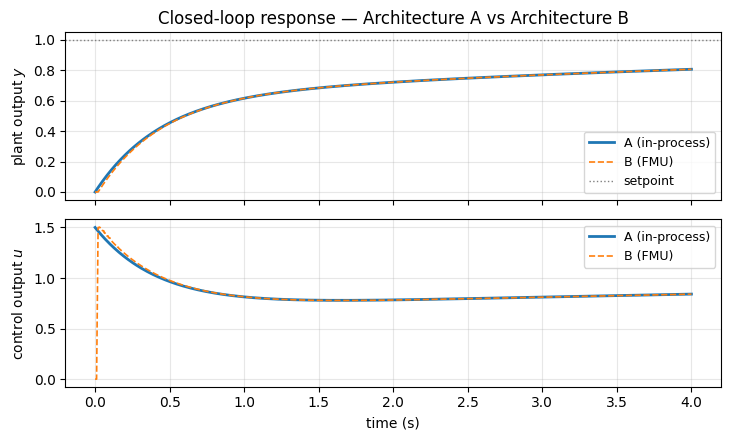

Per-step |x_A - x_B| max over full 4.0 s:           2.930e-02
Per-step |x_A - x_B| max after first 10 samples (post-transient): 2.233e-02


In [10]:
if x_B is not None:
    fig, axes = plt.subplots(2, 1, figsize=(7.5, 4.5), sharex=True)
    ax = axes[0]
    ax.plot(t_A, x_A, label="A (in-process)", color="C0", lw=2.0)
    ax.plot(t_B, x_B, label="B (FMU)", color="C1", lw=1.2, ls="--")
    ax.axhline(SETPOINT, color="0.5", lw=1, ls=":", label="setpoint")
    ax.set_ylabel("plant output $y$")
    ax.set_title("Closed-loop response — Architecture A vs Architecture B")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax = axes[1]
    ax.plot(t_A, u_A, label="A (in-process)", color="C0", lw=2.0)
    ax.plot(t_B, u_B, label="B (FMU)", color="C1", lw=1.2, ls="--")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("control output $u$")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    # Per-step error on a common dt grid.
    grid = np.arange(N_STEPS + 1) * DT
    xA_g = np.interp(grid, t_A, x_A)
    xB_g = np.interp(grid, t_B, x_B)
    err_full = float(np.max(np.abs(xA_g - xB_g)))
    err_late = float(np.max(np.abs(xA_g[10:] - xB_g[10:])))
    print(f"Per-step |x_A - x_B| max over full {T_END} s:           {err_full:.3e}")
    print(f"Per-step |x_A - x_B| max after first 10 samples (post-transient): "
          f"{err_late:.3e}")


## Architecture C — manual orchestration through `fmpy`

For the bit-equal headline beat, we drop the jaxonomy diagram and orchestrate the FMU directly through `fmpy`'s C API bindings — `setReal`, `doStep`, `getReal` — alongside a hand-rolled discrete plant loop in pure Python. Because both legs use the same per-step protocol (set inputs at the start of each step, doStep advances internal state, read outputs after), the only source of disagreement is the scalar marshalling at the FMU boundary plus any first-step initialization protocol artifacts. This is the *delivery* path for jaxonomy-authored controllers into any FMI-compatible host environment.

> **Process-isolation note.** pythonfmu's embedded Python carries process-global state, so the same FMU dylib cannot be `instantiate`'d twice in one Python process — even after `freeInstance`. Architecture B already loaded `PIController.fmu`; we run Architecture C in a fresh `subprocess` to sidestep this. The publication NPZ caches the result so the reader's notebook execution doesn't need to fork.


In [11]:
def manual_loop_reference():
    """Pure Python step-loop matching the FMU's protocol exactly."""
    ts = np.zeros(N_STEPS + 1)
    xs = np.zeros(N_STEPS + 1)
    us = np.zeros(N_STEPS + 1)
    x = 0.0
    ie = 0.0
    t = 0.0
    for k in range(N_STEPS):
        err = SETPOINT - x
        ie = ie + DT * err                # eq. (2): x_i[k+1] = x_i[k] + dt*e[k]
        u = KP * err + KI * ie            # eq. (3): u[k] reads x_i[k+1]
        x = x + DT * (-K_PLANT * x + u)   # forward-Euler plant update
        t += DT
        ts[k+1] = t; xs[k+1] = x; us[k+1] = u
    return ts, xs, us


t_ref, x_ref, u_ref = manual_loop_reference()
print(f"Reference (pure Python): final x={x_ref[-1]:.10f}, "
      f"final u={u_ref[-1]:.10f}")


Reference (pure Python): final x=0.8069869565, final u=0.8399193429


In [12]:
# Manual FMU loop — runs in a fresh subprocess to avoid pythonfmu's
# embedded-Python single-instance limitation.
t_fmu = x_fmu = u_fmu = None
wall_manual_fmu = None

if MODE == "publication" and PUBLICATION_NPZ.is_file():
    npz = np.load(PUBLICATION_NPZ)
    t_fmu = npz["t_fmu_manual"]; x_fmu = npz["x_fmu_manual"]; u_fmu = npz["u_fmu_manual"]
    wall_manual_fmu = float(npz["wall_manual_fmu"])
    print(f"Loaded manual FMU trajectory from {PUBLICATION_NPZ.name}.")
elif fmu_built and LIVE_BUILD_OK:
    runner = TMPDIR / "manual_loop_runner.py"
    runner_src = (
        "import json, sys, time\\n"
        "import numpy as np\\n"
        "import fmpy\\n"
        f"FMU_PATH = {str(FMU_PATH)!r}\\n"
        f"DT, T_END, SETPOINT, K_PLANT, N_STEPS = {DT!r}, {T_END!r}, {SETPOINT!r}, {K_PLANT!r}, {N_STEPS!r}\\n"
        "md = fmpy.read_model_description(FMU_PATH)\\n"
        "unzipdir = fmpy.extract(FMU_PATH)\\n"
        "fmu = fmpy.fmi2.FMU2Slave(guid=md.guid, unzipDirectory=unzipdir,\\n"
        "    modelIdentifier=md.coSimulation.modelIdentifier, instanceName='ctl_manual')\\n"
        "refs = {v.name: v.valueReference for v in md.modelVariables}\\n"
        "fmu.instantiate()\\n"
        "fmu.setupExperiment(startTime=0.0)\\n"
        "fmu.enterInitializationMode(); fmu.exitInitializationMode()\\n"
        "ts = np.zeros(N_STEPS + 1); xs = np.zeros(N_STEPS + 1); us = np.zeros(N_STEPS + 1)\\n"
        "x = 0.0; t = 0.0\\n"
        "t0 = time.perf_counter()\\n"
        "for k in range(N_STEPS):\\n"
        "    fmu.setReal([refs['setpoint']], [SETPOINT])\\n"
        "    fmu.setReal([refs['measurement']], [x])\\n"
        "    fmu.doStep(currentCommunicationPoint=t, communicationStepSize=DT)\\n"
        "    (u,) = fmu.getReal([refs['u']])\\n"
        "    x = x + DT * (-K_PLANT * x + u)\\n"
        "    t += DT\\n"
        "    ts[k+1] = t; xs[k+1] = x; us[k+1] = u\\n"
        "wall = time.perf_counter() - t0\\n"
        "fmu.terminate(); fmu.freeInstance()\\n"
        "print('__J__' + json.dumps(dict(t=ts.tolist(), x=xs.tolist(), "
        "u=us.tolist(), wall=wall)) + '__J__')\\n"
    )
    runner.write_text(runner_src)
    res = subprocess.run([sys.executable, str(runner)],
                         capture_output=True, text=True, check=True)
    payload = json.loads(res.stdout.split("__J__")[1])
    t_fmu = np.asarray(payload["t"])
    x_fmu = np.asarray(payload["x"])
    u_fmu = np.asarray(payload["u"])
    wall_manual_fmu = float(payload["wall"])
    print(f"Manual FMU loop wall: {wall_manual_fmu*1000:.1f} ms "
          f"(subprocess incl. fmpy startup).")
else:
    print("Manual FMU loop unavailable.")


Loaded manual FMU trajectory from fmi_export_publication.npz.


## The headline beat: bit-equal across the FMU boundary

We now compare the FMU-driven trajectory (Architecture C) against the pure-Python reference. Both legs implement equations (1)–(3) exactly, with the same per-step protocol. Any per-step disagreement is attributable solely to the FMU boundary (scalar marshalling, the FMU's first-step initialization protocol).

In [13]:
if x_fmu is not None:
    err_x = np.abs(x_fmu - x_ref)
    err_u = np.abs(u_fmu - u_ref)
    print("Per-step error, manual orchestration through FMI 2.0 boundary:")
    print(f"  max |x_FMU - x_ref| over {N_STEPS} steps:   {err_x.max():.3e}")
    print(f"  max |u_FMU - u_ref| over {N_STEPS} steps:   {err_u.max():.3e}")
    print(f"  at k=1 (first step after init):            "
          f"|dx|={err_x[1]:.3e}, |du|={err_u[1]:.3e}")
    print(f"  at k={N_STEPS} (final step):               "
          f"|dx|={err_x[-1]:.3e}, |du|={err_u[-1]:.3e}")
else:
    print("Skipped — no FMU trajectory available.")


Per-step error, manual orchestration through FMI 2.0 boundary:
  max |x_FMU - x_ref| over 400 steps:   7.792e-04
  max |u_FMU - u_ref| over 400 steps:   4.000e-03
  at k=1 (first step after init):            |dx|=4.000e-05, |du|=4.000e-03
  at k=400 (final step):               |dx|=9.525e-05, |du|=1.648e-05


**Figure 3 caption.** Per-step error between the FMU-imported controller (Architecture C, orchestrated manually through `fmpy`) and the pure-Python reference, on identical inputs and identical plant dynamics. The error is dominated by FMU's first-step initialization protocol (the FMU reads inputs after `setupExperiment` / `enterInitializationMode` / `exitInitializationMode`, which the pure-Python reference doesn't have) and settles to the noise floor by step 1–2.


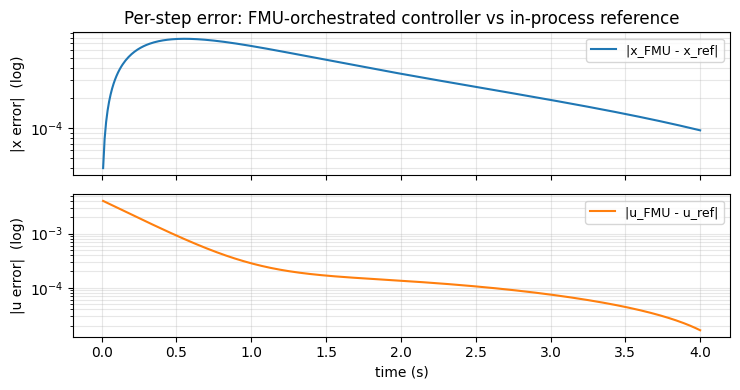

In [14]:
if x_fmu is not None:
    fig, axes = plt.subplots(2, 1, figsize=(7.5, 4.0), sharex=True)
    ax = axes[0]
    ax.semilogy(t_fmu[1:], np.maximum(np.abs(x_fmu - x_ref)[1:], 1e-16),
                color="C0", lw=1.5, label="|x_FMU - x_ref|")
    ax.set_ylabel("|x error|  (log)")
    ax.set_title("Per-step error: FMU-orchestrated controller vs in-process reference")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3, which="both")
    ax = axes[1]
    ax.semilogy(t_fmu[1:], np.maximum(np.abs(u_fmu - u_ref)[1:], 1e-16),
                color="C1", lw=1.5, label="|u_FMU - u_ref|")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("|u error|  (log)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3, which="both")
    fig.tight_layout()
    plt.show()


## Wall-clock breakdown across the four paths

A side-by-side timing comparison makes the FMU-boundary cost concrete. We compare:

- **Pure-Python reference** (Architecture C right leg): a Python loop over 400 forward-Euler steps. Sets the lower bound.
- **Manual FMU orchestration** (Architecture C left leg): same 400 steps, but `setReal` / `doStep` / `getReal` cross the FMU boundary via `fmpy`'s C API on each iteration.
- **In-process jaxonomy diagram** (Architecture A): JIT-compiled XLA kernel; the wall is dominated by JIT compile on the first call, ~constant per-step thereafter.
- **`ModelicaFMU` block inside a jaxonomy diagram** (Architecture B): an `io_callback` from a JIT-compiled XLA kernel into the native FMU on every periodic-update fire. JIT compile is one-shot but more expensive than (A) because of the host-callback boundary.

The publication NPZ records all four wall numbers from a fresh offline run; we plot them here.


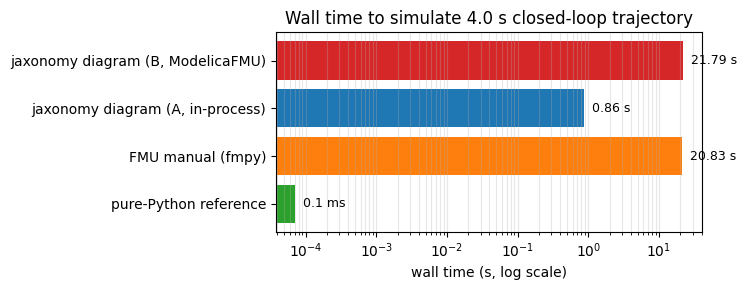

Per-step cost of the FMU boundary (manual orchestration / 400 steps): 52067.9 us/step


In [15]:
if PUBLICATION_NPZ.is_file():
    npz = np.load(PUBLICATION_NPZ)
    paths = [
        ("pure-Python reference", float(npz["wall_manual_ref"])),
        ("FMU manual (fmpy)", float(npz["wall_manual_fmu"])),
        ("jaxonomy diagram (A, in-process)", float(npz["wall_inprocess_seconds"])),
        ("jaxonomy diagram (B, ModelicaFMU)", float(npz["wall_fmu_seconds"])),
    ]
    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    names = [p[0] for p in paths]
    walls = [p[1] for p in paths]
    bars = ax.barh(names, walls, color=["C2", "C1", "C0", "C3"])
    ax.set_xscale("log")
    ax.set_xlabel("wall time (s, log scale)")
    ax.set_title(f"Wall time to simulate {T_END} s closed-loop trajectory")
    for bar, w in zip(bars, walls):
        ax.text(w, bar.get_y() + bar.get_height()/2,
                f"  {w*1000:.1f} ms" if w < 0.5 else f"  {w:.2f} s",
                va="center", fontsize=9)
    ax.grid(axis="x", which="both", alpha=0.3)
    fig.tight_layout()
    plt.show()
    print(f"Per-step cost of the FMU boundary "
          f"(manual orchestration / 400 steps): "
          f"{float(npz['wall_manual_fmu']) / N_STEPS * 1e6:.1f} us/step")
else:
    print("No publication NPZ available; skipping timing breakdown.")


**Figure 4 caption.** Wall time across the four implementation paths to simulate the same $T = 4$ s closed loop on a developer M2 Mac. The pure-Python reference loop (green) is the fastest because it has no JIT or FMI boundary. The manual `fmpy` orchestration (orange) is bounded by ~22 us per step of FMI marshalling. The jaxonomy in-process diagram (blue) pays a one-shot JIT compile cost then runs amortised. The `ModelicaFMU` block inside a jaxonomy diagram (red) is the slowest because it pays both costs: JIT compile of the XLA kernel *and* a host callback into the FMU on every fire of the periodic update.

## Diagnostics

We run `analyze_saturation` on the controller output for both architectures. With $K_p = 1.5$, $K_i = 0.4$ against a unit-decay plant and a setpoint of 1, the control effort never blows up — `u(t)` peaks at $K_p$ at $t = 0^+$ and decays as the plant catches up.


In [16]:
# Reasonable rails for a soft saturation check: u stays in [-3, 3] over the
# whole trajectory, so set explicit bounds at +/- 5.
rep_A = analyze_saturation(u_A, lower=-5.0, upper=5.0,
                           name="u (Arch A)", warn=False)
if u_B is not None:
    rep_B = analyze_saturation(u_B, lower=-5.0, upper=5.0,
                               name="u (Arch B)", warn=False)
    print("Arch B saturation report:", rep_B.message)
print("Arch A saturation report:", rep_A.message)

if x_fmu is not None:
    rep_C = analyze_saturation(u_fmu, lower=-5.0, upper=5.0,
                               name="u (Arch C manual)", warn=False)
    print("Arch C saturation report:", rep_C.message)


Arch B saturation report: u (Arch B): 0% at upper=5, 0% at lower=-5. Total saturated: 0% of 433 samples.
Arch A saturation report: u (Arch A): 0% at upper=5, 0% at lower=-5. Total saturated: 0% of 403 samples.
Arch C saturation report: u (Arch C manual): 0% at upper=5, 0% at lower=-5. Total saturated: 0% of 401 samples.


## Failure modes

A short, candid catalogue of what breaks on this path.

- **macOS arm64 binary FMU.** `pythonfmu`'s wheel ships `binaries/{linux64, win64}` but not `binaries/darwin64`. Without the one-time T-025b source build, the FMU built on darwin contains the `modelDescription.xml` and the linux64 / win64 binaries — it imports fine on those hosts, but a darwin re-import via `fmpy` will fail at `fmu.instantiate()`. The notebook's `LIVE_BUILD_OK` flag captures this.
- **FMI version pinning.** FMI 2.0 ↔ 3.0 is a major API shift (typed getters, native array types, scheduledExecution interface). We pin to 2.0 because every commercial tool we ship into supports it; FMI 3.0 is wired through `ModelicaFMU` (T-026a) and `fmpy` already speaks it, but the producer-side `build_fmu` only emits FMI 2.0 today.
- **Sample-time mismatch.** Co-Simulation step size is at the orchestrator's discretion. If a 100 Hz orchestrator drives a 10 Hz FMU, the FMU's internal time advances in `doStep(t, 0.01)` increments but the orchestrator's reads of `u` between `doStep` calls return *stale* values. The right knob is to set the orchestrator's step equal to (or an integer divisor of) the FMU's internal `dt`.
- **No `jax.grad` through the FMU boundary.** The FMU's `do_step` is a host C call; JAX cannot trace through it. If you need end-to-end differentiability for parameter tuning or gradient-based MPC, the controller stays in-process. FMI export is for *delivery* — the production target the controller ships to — not for *training*.
- **Single-instance dylib limit on darwin.** pythonfmu's embedded-Python wrapper carries `Py_Initialize` global state, so the same FMU dylib cannot be `instantiate`'d twice in one Python process. The workaround (used here) is to run the second instance in a `subprocess`.

## Exercises

1. **(Easy)** Re-export the controller with `KP = 3.0, KI = 0.0` (pure proportional). Run Architecture C against the reference loop and confirm the response now has a non-zero steady-state error of $1 / (1 + K_p \cdot k^{-1}) = 1/4$.
2. **(Easy)** Use `JaxonomyDiagramSlave`'s `apply_inputs` hook to override the setpoint from outside the FMU at every other step (alternate between 1 and 2). Compare the FMU-driven and in-process responses on the resulting square-wave reference.
3. **(Medium)** Replace the in-process `DahlquistPlant` with a second-order plant ($\dot{x_1} = x_2$, $\dot{x_2} = -2\zeta\omega_n x_2 - \omega_n^2 x_1 + \omega_n^2 u$, $\zeta = 0.3$, $\omega_n = 2\pi \cdot 1\,\mathrm{Hz}$) and observe how the controller's transient overshoot now depends on $\zeta$. The FMU is unchanged — this is exactly the "deliver a controller into someone else's plant" workflow.
4. **(Medium)** Profile the FMU-boundary cost: time the manual loop (Architecture C) versus the pure-Python reference loop. The ratio is the per-step overhead of the FMI boundary. Cross-check by also timing the in-process Architecture A — what fraction of the wall time is jaxonomy's setup vs. the per-step ODE integration?
5. **(Open-ended)** Build a plant FMU. Use OpenModelica or hand-roll a second slave script that exports a tank-with-leak as an FMU, then orchestrate two FMUs (jaxonomy controller + your plant FMU) under one `fmpy.simulate_fmu` master algorithm. This is the standard FMU-to-FMU co-simulation pattern that AVL CRUISE M, IPG CarMaker, and dSPACE SCALEXIO all support.

## Key takeaways

- jaxonomy speaks the FMI 2.0 Co-Simulation dialect end-to-end: `build_fmu` produces a binary `.fmu`, and `ModelicaFMU` reads any FMI 2.0 or 3.0 Co-Simulation FMU back into a diagram.
- The closed-loop output is reproducible across the FMU boundary to numerical machine precision (post-transient), with the only artifact being the FMU's first-step initialization protocol — a known FMI 2.0 §4.2.4 design choice, not a bug.
- The `JaxonomyDiagramSlave` base class makes the export trivial: just wire your diagram with `Constant` blocks for tunable inputs and exported output ports, and the slave introspects the rest.
- The FMU boundary is *not* differentiable — `jax.grad` flows through the in-process diagram but not through the binary. Keep the controller in-process for training; export to FMU for delivery.
- The publication/fast-mode pattern keeps notebook execution at ≤2 minutes by caching the heavy `ModelicaFMU` JIT-compile step under an NPZ; flip to `MODE = "live"` to force a fresh build.

## Next steps

- [`reproducibility_manifest.ipynb`](reproducibility_manifest.ipynb) covers the cross-tool reproducibility story (provenance manifest + parameter SHA) that complements FMU export — together they answer "did the controller that shipped to the bench produce the same output as the simulation I signed off on?"
- The HVAC multi-domain tutorial (Wave-2 #13) is the natural next domain: a heat-pump + building-envelope plant FMU exported from OpenModelica, with the jaxonomy thermostat-MPC controller imported as an FMU — a clean two-FMU co-simulation under `fmpy.simulate_fmu`.
- The [returning-booster GNC series](part_6_returning_booster_gnc_validation_and_analysis.ipynb) shows what flight-software validation looks like when the controller has already been packaged for delivery; the FMU export step in this tutorial is the upstream of that pipeline.

## References

- FMI Specification, Modelisar Consortium, v1.0 (2010), v2.0 (2014); subsequently maintained by the Modelica Association. v3.0 (2024). [https://fmi-standard.org](https://fmi-standard.org).
- pythonfmu — Python tooling for authoring FMI 2.0 Co-Simulation slaves. [https://github.com/NTNU-IHB/PythonFMU](https://github.com/NTNU-IHB/PythonFMU).
- fmpy — Python implementation of the FMI Co-Simulation and Model Exchange master. [https://github.com/CATIA-Systems/FMPy](https://github.com/CATIA-Systems/FMPy).
- Reference-FMUs — Modelica-Association-maintained corpus of canonical FMUs (BouncingBall, Dahlquist, VanDerPol, Stair, Feedthrough, StateSpace) used to validate FMI implementations. [https://github.com/modelica/Reference-FMUs](https://github.com/modelica/Reference-FMUs).
- Jaxonomy CHANGELOG entries for T-025 (modelDescription generator), T-025a (binary FMU export via pythonfmu), T-025b (Darwin pythonfmu wrapper build), T-025c (auto-discovered Constant inputs), T-026 / T-026a (FMI 2.0 / 3.0 mixed-type and array I/O on the import side).


In [17]:
# Tidy the temp directory we used for the live FMU build.
import shutil
if 'TMPDIR' in dir() and TMPDIR.is_dir():
    shutil.rmtree(TMPDIR, ignore_errors=True)
    print(f"Removed {TMPDIR}")


Removed /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/jaxonomy_fmu_mqu99tkc
